In [16]:
import pandas as pd
from sklearn.utils import shuffle

In [17]:
df = pd.read_csv("pulsar_data_train.csv")

In [18]:
df['target_class'].value_counts()

0.0    11375
1.0     1153
Name: target_class, dtype: int64

In [19]:
class_0 = df[df['target_class'] == 0]
class_1 = df[df['target_class'] == 1]

In [20]:
class_0_sample = class_0.sample(n=1100, random_state=42)
class_1_sample = class_1.sample(n=1100, random_state=42)

In [21]:
balanced_df.shape
balanced_df.columns

NameError: name 'balanced_df' is not defined

In [12]:
balanced_df.info()
balanced_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                2200 non-null   float64
 1    Standard deviation of the integrated profile  2200 non-null   float64
 2    Excess kurtosis of the integrated profile     1908 non-null   float64
 3    Skewness of the integrated profile            2200 non-null   float64
 4    Mean of the DM-SNR curve                      2200 non-null   float64
 5    Standard deviation of the DM-SNR curve        1996 non-null   float64
 6    Excess kurtosis of the DM-SNR curve           2200 non-null   float64
 7    Skewness of the DM-SNR curve                  2083 non-null   float64
 8   target_class                                   2200 non-null   float64
dtypes: float64(9)
memory usage: 154.8 KB


 Mean of the integrated profile                    0
 Standard deviation of the integrated profile      0
 Excess kurtosis of the integrated profile       292
 Skewness of the integrated profile                0
 Mean of the DM-SNR curve                          0
 Standard deviation of the DM-SNR curve          204
 Excess kurtosis of the DM-SNR curve               0
 Skewness of the DM-SNR curve                    117
target_class                                       0
dtype: int64

In [14]:
balanced_df.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,2200.000000,2200.000000,1908.000000,2200.000000,2200.000000,1996.000000,2200.000000,2083.000000,2200.000000
mean,86.366456,42.985199,1.656276,7.959180,29.843844,40.223953,5.763375,64.466301,0.500000
std,38.564533,8.212711,1.982989,12.564402,42.120733,24.933479,4.797153,93.336359,0.500114
min,5.812500,24.772042,-1.118709,-1.334542,0.282609,7.565681,-2.282560,-1.931996,0.000000
25%,54.308594,36.687621,0.174949,0.093709,2.506480,17.143182,1.592888,1.562604,0.000000
50%,95.492188,43.471060,0.606350,1.295904,6.852007,32.329711,5.196643,27.798758,0.500000
75%,117.089844,49.152527,2.873258,11.206401,40.730978,63.073670,9.085017,97.677544,1.000000
max,167.593750,79.084407,8.069522,68.101622,200.500000,109.655345,32.198584,1072.957979,1.000000


In [22]:
import numpy as np

np.isinf(balanced_df).sum()

NameError: name 'balanced_df' is not defined

In [6]:
balanced_df = pd.concat([class_0_sample, class_1_sample])

In [7]:
balanced_df = shuffle(balanced_df, random_state=42).reset_index(drop=True)

In [8]:
balanced_df['target_class'].value_counts()

1.0    1100
0.0    1100
Name: target_class, dtype: int64

In [9]:
small_class_0 = balanced_df[balanced_df['target_class'] == 0].sample(n=300, random_state=42)
small_class_1 = balanced_df[balanced_df['target_class'] == 1].sample(n=300, random_state=42)

small_balanced_df = pd.concat([small_class_0, small_class_1])
small_balanced_df = shuffle(small_balanced_df, random_state=42).reset_index(drop=True)

In [10]:
small_balanced_df['target_class'].value_counts()

0.0    300
1.0    300
Name: target_class, dtype: int64

In [15]:
balanced_df.groupby('target_class').mean()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve
target_class,,,,,,,,
0.0,116.141847,47.224517,0.207829,0.386872,9.640332,23.428738,8.748657,110.790021
1.0,56.591065,38.745882,3.119986,15.531489,50.047356,56.918499,2.778094,18.008954


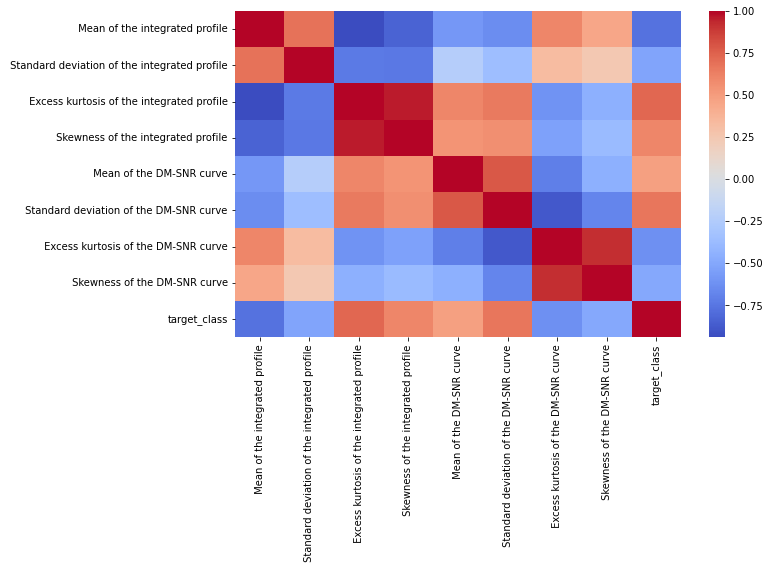

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(balanced_df.corr(), cmap='coolwarm')
plt.show()

In [17]:
X = balanced_df.drop('target_class', axis=1)
y = balanced_df['target_class']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').